# Pulling, Processing and Saving Our Data

In this short notebook, we will pull our daily close dataset using `yfinance`, inspect it for missing values, create columns for daily returns, log price and log returns, and save it in the `data/` folder.

We will use Procter and Gamble (PG) as our asset for this exploration as it has several decades of stable, liquid price history. This puts the data closer to the 'textbook' example than more volatile or eratic stocks.

In [1]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import pandas_market_calendars as mcal

In [2]:
df = yf.download(tickers="PG", interval="1d", period="max", group_by="ticker", auto_adjust=True)

df.columns = df.columns.droplevel(0)
df.columns.name = None
df.columns = df.columns.str.lower()
df.index.name = "date"

[*********************100%***********************]  1 of 1 completed


## Inspection

In [3]:
df

,open,high,low,close,volume
date,,,,,
1962-01-02,0.241323,0.244638,0.241323,0.242649,192000
1962-01-03,0.242649,0.242649,0.238008,0.239997,428800
1962-01-04,0.239997,0.240660,0.236019,0.236019,326400
1962-01-05,0.236019,0.236682,0.231378,0.234361,544000
1962-01-08,0.233036,0.233036,0.225411,0.228063,1523200
...,...,...,...,...,...
2026-09-08,145.600006,146.160004,144.300003,145.580002,8325100
2026-09-09,144.160004,144.470001,142.339996,142.639999,9270000
2026-09-10,142.600006,143.509995,141.860001,142.970001,10925000


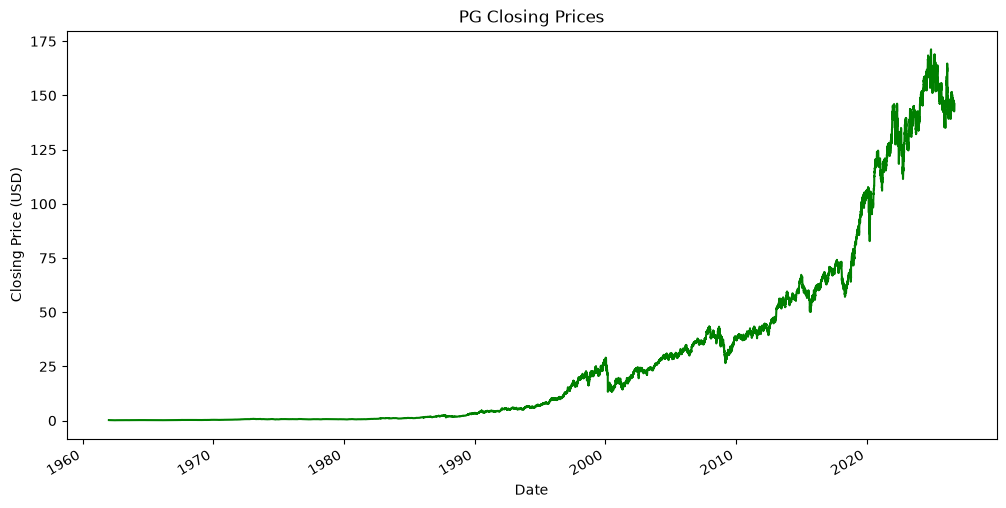

In [4]:
plt.figure(figsize=(12, 6))

df["close"].plot(color="green")

plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.title("PG Closing Prices")

plt.show()

## Completeness checks

In [5]:
df.dtypes

open      float64
high      float64
low       float64
close     float64
volume      int64
dtype: object

In [6]:
nyse = mcal.get_calendar("NYSE")
valid_days = nyse.valid_days(start_date=min(df.index), end_date=max(df.index))
valid_days = valid_days.tz_localize(None).normalize()
missing_days = valid_days.difference(df.index)

print("Number of rows: ", len(df))
print("Number of missing rows: ", len(missing_days))

Number of rows:  16283
Number of missing rows:  0


In [7]:
issue_found = False

for col in df.columns:
    zeros = sum(df[col] == 0)
    negatives = sum(df[col] < 0)
    nulls = sum(df[col].isna())
    if zeros != 0:
        issue_found = True
        print(zeros, " zero(s) found in ", col)
    if negatives != 0:
        issue_found = True
        print(negatives, " negative(s) found in ", col)
    if nulls != 0:
        issue_found = True
        print(nulls, " null(s) found in ", col)

if not issue_found:
    print("dataset is complete!")

dataset is complete!


## Daily Returns, Log Price and Log Returns

In [8]:
df["daily_return"] = df["close"].diff()
df["pct_return"] = df["close"].pct_change()
df["log_close"] = np.log(df["close"])
df["log_return"] = df["log_close"].diff()


In [9]:
df

,open,high,low,close,volume,daily_return,pct_return,log_close,log_return
date,,,,,,,,,
1962-01-02,0.241323,0.244638,0.241323,0.242649,192000,NaN,NaN,-1.416140,NaN
1962-01-03,0.242649,0.242649,0.238008,0.239997,428800,-0.002652,-0.010929,-1.427129,-0.010989
1962-01-04,0.239997,0.240660,0.236019,0.236019,326400,-0.003978,-0.016575,-1.443843,-0.016714
1962-01-05,0.236019,0.236682,0.231378,0.234361,544000,-0.001657,-0.007022,-1.450891,-0.007047
1962-01-08,0.233036,0.233036,0.225411,0.228063,1523200,-0.006298,-0.026874,-1.478132,-0.027241
...,...,...,...,...,...,...,...,...,...
2026-09-08,145.600006,146.160004,144.300003,145.580002,8325100,-0.860001,-0.005873,4.980726,-0.005890
2026-09-09,144.160004,144.470001,142.339996,142.639999,9270000,-2.940002,-0.020195,4.960324,-0.020402
2026-09-10,142.600006,143.509995,141.860001,142.970001,10925000,0.330002,0.002314,4.962635,0.002311


## Saving

In [10]:
df.to_csv("../data/pg_daily.csv", index=True)